# Báo cáo phân tích điểm thi trung học phổ thông

## Tóm tắt các phát hiện chính

Báo cáo phân tích hai vấn đề có ý nghĩa đối với việc diễn giải kết quả thi: (i) môn học nào tạo ra phần lớn chênh lệch giữa Bắc, Trung và Nam; và (ii) kết luận so sánh KHTN với KHXH có thay đổi khi chuyển từ điểm gốc sang thước đo tương đối theo từng môn hay không.

### Phát hiện 1: Chênh lệch vùng miền phụ thuộc vào môn học và chỉ số đánh giá

Ngoại ngữ có khoảng cách lớn nhất về điểm trung bình giữa vùng cao nhất và vùng thấp nhất. Tuy nhiên, khi xét tỷ lệ thí sinh đạt từ 8 điểm trở lên, Ngữ văn mới là môn có chênh lệch lớn nhất. Vì vậy, môn dẫn đầu về khoảng cách mặt bằng chung không nhất thiết là môn dẫn đầu về phân hóa ở nhóm điểm cao.

### Phát hiện 2: Kết luận về KHTN và KHXH phụ thuộc vào thước đo

Theo điểm gốc, KHTN chỉ cao hơn KHXH trong 3/9 tổ hợp vùng–năm. Sau khi chuẩn hóa từng môn theo mặt bằng điểm của chính môn đó trong cùng năm, KHTN cao hơn trong cả 9/9 tổ hợp.

### Kết luận tổng quát

Việc đánh giá kết quả thi cần đồng thời xem xét môn học, phân vị điểm và mục tiêu so sánh. Một bảng xếp hạng dựa trên điểm gốc có thể mô tả chính xác số điểm thí sinh nhận được, nhưng chưa chắc phản ánh đầy đủ vị trí tương đối của thí sinh trong từng môn thi.

## Mục tiêu, phạm vi và cách tiếp cận

### Mục tiêu nghiên cứu

Báo cáo trả lời hai câu hỏi nghiên cứu:

1. Trong giai đoạn 2022–2024, môn học nào tạo ra chênh lệch lớn nhất về kết quả giữa Bắc, Trung và Nam?
2. Kết luận so sánh KHTN và KHXH thay đổi như thế nào khi phân biệt điểm gốc với vị trí tương đối của thí sinh trong từng môn?

Mục tiêu của phân tích không phải là xây dựng một bảng xếp hạng đơn nhất, mà là xác định cấu trúc phía sau các chênh lệch quan sát được: chênh lệch tập trung ở môn nào, xuất hiện rõ ở nhóm điểm nào và có phụ thuộc vào phương pháp đo lường hay không.

### Phạm vi dữ liệu

| Hạng mục | Thiết lập phân tích |
|---|---|
| Chương trình | CT2006 |
| Giai đoạn | 2022–2024 |
| Phân tích vùng | Bắc, Trung, Nam; 9 môn thi |
| Phân tích ban | Thí sinh có đủ 5 môn lõi của KHTN hoặc KHXH |
| Đơn vị so sánh | Năm, vùng, môn học và ban thi |
| Giá trị thiếu | Loại trừ theo môn; không quy đổi thành 0 |

### Cấu trúc báo cáo

Mỗi câu hỏi được trình bày theo cùng một cấu trúc: câu hỏi nghiên cứu, cơ sở phân tích, phương pháp, kết quả, diễn giải, hàm ý và giới hạn. Cách trình bày này giúp phân biệt rõ giữa kết quả thống kê, diễn giải từ kết quả và những kết luận chưa thể suy ra từ dữ liệu.

In [1]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["svg.fonttype"] = "none"

candidates = [Path("data/processed/final_data.csv"), Path("../data/processed/final_data.csv")]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/processed/final_data.csv")

SUBJECTS = ["toan", "ngu_van", "ngoai_ngu", "vat_li", "hoa_hoc", "sinh_hoc", "lich_su", "dia_li", "gdcd"]
LABELS = {
    "toan": "Toán",
    "ngu_van": "Ngữ văn",
    "ngoai_ngu": "Ngoại ngữ",
    "vat_li": "Vật lí",
    "hoa_hoc": "Hóa học",
    "sinh_hoc": "Sinh học",
    "lich_su": "Lịch sử",
    "dia_li": "Địa lí",
    "gdcd": "GDCD",
}
SUBJECT_ORDER = SUBJECTS
REGION_ORDER = ["Bắc", "Trung", "Nam"]
USECOLS = ["nam", "chuong_trinh", "ban", "vung_3"] + SUBJECTS

# Thống kê theo năm–vùng–môn:
# số bài hợp lệ, tổng điểm, số điểm từ 8, số điểm dưới 5.
regional_stats = defaultdict(lambda: [0, 0.0, 0, 0])

# Histogram theo từng 0,01 điểm để tính trung vị mà không phải giữ toàn bộ dữ liệu trong bộ nhớ.
regional_hist = defaultdict(lambda: np.zeros(1001, dtype=np.int64))

# Tham số phân phối cấp quốc gia theo năm–môn: n, tổng điểm, tổng bình phương.
national = defaultdict(lambda: [0, 0.0, 0.0])

# Thống kê ban: số dòng, số dòng đủ 5 môn lõi, tổng điểm trung bình lõi,
# số dòng có điểm lõi TB từ 7 và từ 8.
ban_stats = defaultdict(lambda: [0, 0, 0.0, 0, 0])
ban_subject_sums = defaultdict(lambda: [0, 0.0])

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=USECOLS,
    chunksize=500_000,
    low_memory=False,
    dtype={"chuong_trinh": "string", "ban": "string"},
):
    d = chunk[
        (chunk["nam"].between(2022, 2024))
        & (chunk["chuong_trinh"] == "2006")
    ].copy()

    if d.empty:
        continue

    for col in SUBJECTS:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Phân tích khoảng cách vùng: mỗi môn dùng toàn bộ thí sinh có điểm hợp lệ ở môn đó.
    for (year, region), group in d.groupby(["nam", "vung_3"], sort=False):
        year, region = int(year), str(region)
        for col in SUBJECTS:
            values = group[col].dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue

            key = (year, region, col)
            item = regional_stats[key]
            item[0] += len(values)
            item[1] += float(values.sum())
            item[2] += int((values >= 8).sum())
            item[3] += int((values < 5).sum())

            rounded = np.clip(np.rint(values * 100).astype(int), 0, 1000)
            regional_hist[key] += np.bincount(rounded, minlength=1001)

    # Phân phối quốc gia dùng để chuẩn hóa điểm trong câu hỏi 2.
    for year, group in d.groupby("nam", sort=False):
        year = int(year)
        for col in SUBJECTS:
            values = group[col].dropna().to_numpy(dtype=float)
            item = national[(year, col)]
            item[0] += len(values)
            item[1] += float(values.sum())
            item[2] += float((values * values).sum())

    # Phân tích KHTN–KHXH.
    for (year, region, ban), group in d[
        d["ban"].isin(["KHTN", "KHXH"])
    ].groupby(["nam", "vung_3", "ban"], sort=False):
        year, region, ban = int(year), str(region), str(ban)
        core_cols = (
            ["toan", "ngu_van", "vat_li", "hoa_hoc", "sinh_hoc"]
            if ban == "KHTN"
            else ["toan", "ngu_van", "lich_su", "dia_li", "gdcd"]
        )
        core = group[core_cols].dropna()
        core_mean = core.mean(axis=1)
        key = (year, region, ban)
        item = ban_stats[key]
        item[0] += len(group)
        item[1] += len(core_mean)
        item[2] += float(core_mean.sum())
        item[3] += int((core_mean >= 7).sum())
        item[4] += int((core_mean >= 8).sum())

        for col in core_cols:
            item2 = ban_subject_sums[(key, col)]
            item2[0] += len(core)
            item2[1] += float(core[col].sum())

print(f"Đã đọc dữ liệu CT2006 2022–2024 từ: {DATA_PATH}")
print(f"Số nhóm năm–vùng–môn: {len(regional_stats)}")


Đã đọc dữ liệu CT2006 2022–2024; số nhóm năm–vùng–môn: 81


## 1. Môn học nào tạo ra chênh lệch giữa Bắc, Trung và Nam?

### Câu hỏi nghiên cứu

Trong giai đoạn 2022–2024, chênh lệch kết quả giữa Bắc, Trung và Nam tập trung ở môn học nào? Mức độ chênh lệch có nhất quán giữa điểm trung bình, trung vị và tỷ lệ thí sinh đạt từ 8 điểm trở lên hay không?

### Cơ sở phân tích

So sánh điểm trung bình tổng hợp có thể che khuất sự khác biệt giữa các môn. Một vùng có thể có mặt bằng điểm tốt ở Toán nhưng không có cùng lợi thế ở Ngoại ngữ; tương tự, sự ổn định của điểm trung bình không đồng nghĩa với tỷ lệ thí sinh đạt nhóm điểm cao lớn hơn.

Do đó, kết quả được tách theo môn học và theo ba chỉ số: điểm trung bình, trung vị và tỷ lệ đạt từ 8 điểm trở lên. Cách tiếp cận này cho phép xác định liệu chênh lệch vùng miền chủ yếu nằm ở mặt bằng chung hay ở khả năng hình thành nhóm điểm cao.

### Phương pháp

- Phân tích 9 môn thi thuộc CT2006 trong giai đoạn 2022–2024.
- Với mỗi năm, vùng và môn học, tính điểm trung bình, trung vị và tỷ lệ bài thi đạt từ 8 điểm trở lên.
- Với mỗi môn, xác định khoảng cách giữa vùng có giá trị cao nhất và vùng có giá trị thấp nhất trong từng năm.
- Tổng hợp kết quả theo hai nhóm chỉ số:
  - **Mặt bằng chung:** khoảng cách về điểm trung bình và trung vị.
  - **Nhóm điểm cao:** khoảng cách về tỷ lệ đạt từ 8 điểm trở lên.
- Chỉ sử dụng các bài thi có điểm hợp lệ ở môn đang phân tích; giá trị thiếu được loại trừ và không được mã hóa thành 0.

In [2]:
regional_rows = []
for (year, region, col), item in sorted(regional_stats.items()):
    n, total, ge8, lt5 = item
    cumulative = np.cumsum(regional_hist[(year, region, col)])
    middle_positions = [(n - 1) // 2, n // 2]
    middle_values = [
        np.searchsorted(cumulative, position + 1, side="left")
        for position in middle_positions
    ]
    median = float(np.mean(middle_values)) / 100

    regional_rows.append(
        {
            "Năm": year,
            "Vùng": region,
            "Môn": LABELS[col],
            "Môn_code": col,
            "Số bài hợp lệ": n,
            "Điểm trung bình": total / n,
            "Trung vị": median,
            "Từ 8 điểm (%)": 100 * ge8 / n,
            "Dưới 5 điểm (%)": 100 * lt5 / n,
        }
    )

regional_df = pd.DataFrame(regional_rows)
regional_df["Môn"] = pd.Categorical(
    regional_df["Môn"],
    categories=[LABELS[col] for col in SUBJECT_ORDER],
    ordered=True,
)
regional_df["Vùng"] = pd.Categorical(
    regional_df["Vùng"],
    categories=REGION_ORDER,
    ordered=True,
)

gap_rows = []
for (year, subject), group in regional_df.groupby(["Năm", "Môn"], observed=True):
    mean_high = group.loc[group["Điểm trung bình"].idxmax()]
    mean_low = group.loc[group["Điểm trung bình"].idxmin()]
    gap_rows.append(
        {
            "Năm": year,
            "Môn": subject,
            "Vùng cao nhất (TB)": mean_high["Vùng"],
            "Vùng thấp nhất (TB)": mean_low["Vùng"],
            "Khoảng cách TB (điểm)": mean_high["Điểm trung bình"] - mean_low["Điểm trung bình"],
            "Khoảng cách trung vị (điểm)": group["Trung vị"].max() - group["Trung vị"].min(),
            "Chênh lệch từ 8 (điểm %)": group["Từ 8 điểm (%)"].max() - group["Từ 8 điểm (%)"].min(),
        }
    )

gap_df = pd.DataFrame(gap_rows)
subject_summary = (
    gap_df.groupby("Môn", observed=True)
    .agg(
        {
            "Khoảng cách TB (điểm)": "mean",
            "Khoảng cách trung vị (điểm)": "mean",
            "Chênh lệch từ 8 (điểm %)": "mean",
        }
    )
    .reset_index()
    .sort_values("Khoảng cách TB (điểm)", ascending=False)
)

display(Markdown("### Bảng 1 — Khoảng cách giữa vùng cao nhất và thấp nhất theo từng môn"))
display(
    gap_df[
        [
            "Năm",
            "Môn",
            "Vùng cao nhất (TB)",
            "Vùng thấp nhất (TB)",
            "Khoảng cách TB (điểm)",
            "Khoảng cách trung vị (điểm)",
            "Chênh lệch từ 8 (điểm %)",
        ]
    ].round(2)
)

display(Markdown("### Bảng 2 — Mức chênh lệch trung bình trong giai đoạn 2022–2024"))
display(subject_summary.round(2))

display(Markdown(
    "Mỗi dòng cho biết khoảng cách giữa vùng có kết quả cao nhất và vùng có kết quả thấp nhất. "
    "Ví dụ, nếu **Chênh lệch từ 8 = 15 điểm %**, nghĩa là tỷ lệ thí sinh đạt từ 8 điểm "
    "ở hai vùng chênh nhau khoảng 15 điểm phần trăm."
))


### Bảng 1 — Khoảng cách giữa vùng cao nhất và thấp nhất theo từng môn

 Năm       Môn Vùng cao nhất (TB) Vùng thấp nhất (TB)  Khoảng cách TB (điểm)  Khoảng cách trung vị (điểm)  Chênh lệch từ 8 (điểm %)
2022      Toán                Nam               Trung                   0.30                         0.20                      4.98
2022   Ngữ văn                Bắc                 Nam                   0.32                         0.25                     13.10
2022 Ngoại ngữ                Nam               Trung                   0.61                         0.80                      5.31
2022    Vật lí                Bắc                 Nam                   0.55                         0.75                     17.01
2022   Hóa học                Bắc                 Nam                   0.29                         0.50                     12.31
2022  Sinh học                Nam               Trung                   0.21                         0.25                      0.47
2022   Lịch sử                Bắc               Trung                   0.36

### Bảng 2 — Mức chênh lệch trung bình trong giai đoạn 2022–2024

      Môn  Khoảng cách TB (điểm)  Khoảng cách trung vị (điểm)  Chênh lệch từ 8 (điểm %)
Ngoại ngữ                   0.56                         0.73                      5.66
   Vật lí                   0.53                         0.67                     15.69
  Ngữ văn                   0.37                         0.50                     16.00
     GDCD                   0.33                         0.33                     11.70
     Toán                   0.33                         0.20                      4.94
  Lịch sử                   0.28                         0.33                      5.40
 Sinh học                   0.22                         0.25                      1.37
   Địa lí                   0.22                         0.25                      4.66
  Hóa học                   0.19                         0.25                     10.00

Hình minh họa được xuất trực tiếp từ component biểu đồ của ứng dụng dashboard và bao gồm tiêu đề, chú thích cùng toàn bộ vùng biểu đồ.

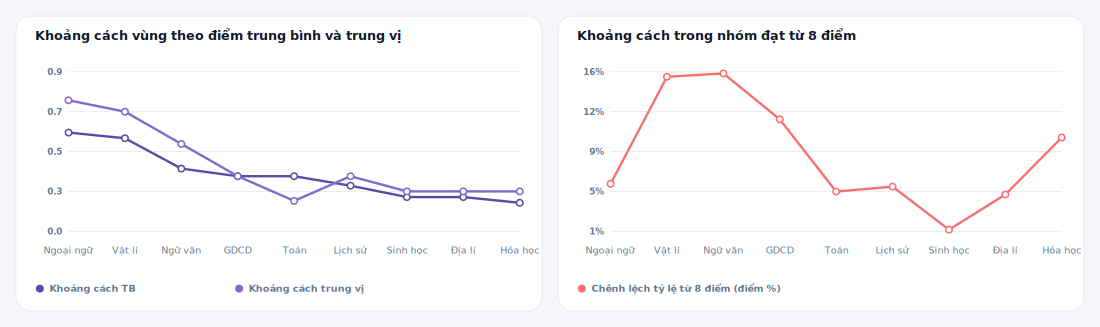

In [5]:
from IPython.display import Markdown, SVG, display
from pathlib import Path

ASSET_DIR = Path('../frontend/public/report')
display(Markdown('Hình minh họa được xuất trực tiếp từ component biểu đồ của ứng dụng dashboard và bao gồm tiêu đề, chú thích cùng toàn bộ vùng biểu đồ.'))
display(SVG(filename=str(ASSET_DIR / 'regional.svg')))


## Câu hỏi 1 — Kết quả và diễn giải

### Kết quả: mặt bằng chung

Biểu đồ bên trái tổng hợp khoảng cách giữa vùng có điểm cao nhất và vùng có điểm thấp nhất trong giai đoạn 2022–2024. Ngoại ngữ có khoảng cách trung bình lớn nhất (**0,56 điểm**), tiếp theo là Vật lí (**0,53 điểm**). Trung vị cho thấy cùng một cấu trúc tổng quát, nhưng mức chênh lệch có thể thay đổi tùy môn.

### Kết quả: nhóm đạt điểm cao

Biểu đồ bên phải cho thấy khi chuyển sang tỷ lệ đạt từ 8 điểm trở lên, thứ hạng thay đổi: Ngữ văn có chênh lệch lớn nhất (**16,0 điểm phần trăm**), tiếp theo là Vật lí (**15,7 điểm phần trăm**).

Hai biểu đồ vì vậy cung cấp hai kết luận bổ sung: Ngoại ngữ là môn có khoảng cách lớn nhất về mặt bằng điểm trung bình, còn Ngữ văn là môn có phân hóa lớn nhất ở nhóm điểm cao.

### Trả lời câu hỏi nghiên cứu

**Chênh lệch vùng miền không tập trung ở một môn duy nhất. Ngoại ngữ dẫn đầu về khoảng cách điểm trung bình, trong khi Ngữ văn dẫn đầu về chênh lệch tỷ lệ đạt từ 8 điểm trở lên.** Đây là kết luận trực tiếp từ hai chỉ số được thể hiện trên biểu đồ.

Do đó, câu hỏi “vùng nào có kết quả tốt hơn?” cần được gắn với chỉ số đánh giá cụ thể. Nếu mục tiêu là đánh giá mặt bằng chung, cần ưu tiên Ngoại ngữ và Vật lí; nếu mục tiêu là xem xét nhóm điểm cao, cần chú ý Ngữ văn và Vật lí.

### Hàm ý sử dụng kết quả

- Báo cáo vùng miền nên trình bày đồng thời khoảng cách về điểm trung bình, trung vị và tỷ lệ đạt ngưỡng.
- Phân tích can thiệp hoặc phân bổ nguồn lực nên gắn với từng môn học, thay vì gán một đặc điểm chung cho toàn vùng.
- Dashboard nên cung cấp khả năng chuyển đổi giữa mặt bằng chung và nhóm điểm cao để hạn chế diễn giải một chiều.

### Giới hạn

Các biểu đồ tổng hợp khoảng cách theo môn trong toàn giai đoạn, nên không thể hiện hướng chênh lệch của từng vùng trong từng năm. Phân tích cũng mô tả sự khác biệt quan sát được nhưng không xác định nguyên nhân nhân quả. Kết quả có thể chịu ảnh hưởng của độ khó đề thi, lựa chọn môn, điều kiện học tập và thành phần thí sinh.

## 2. KHTN và KHXH: lợi thế của điểm gốc hay lợi thế của thước đo?

### Câu hỏi nghiên cứu

Ban KHTN hay KHXH có kết quả tốt hơn? Câu trả lời có thay đổi khi so sánh điểm gốc với vị trí tương đối của thí sinh trong mặt bằng điểm của từng môn hay không?

### Cơ sở phân tích

Các môn thi có mặt bằng điểm và độ phân tán khác nhau. KHTN có thể bao gồm những môn thường đạt điểm thấp hơn, trong khi KHXH có thể bao gồm những môn có mặt bằng điểm cao hơn. Khi đó, điểm trung bình của ban phản ánh đồng thời kết quả của thí sinh và cơ cấu môn thi.

Vì vậy, một phép so sánh có thể chính xác về mặt số học nhưng chưa phù hợp với mục tiêu nghiên cứu. Cần phân biệt câu hỏi “thí sinh nhận được bao nhiêu điểm?” với câu hỏi “thí sinh đứng ở vị trí nào so với những người thi cùng môn?”.

### Phương pháp

- KHTN gồm Toán, Ngữ văn, Vật lí, Hóa học và Sinh học.
- KHXH gồm Toán, Ngữ văn, Lịch sử, Địa lí và GDCD.
- Chỉ giữ các thí sinh có đủ 5 môn lõi tương ứng với ban thi.
- Tính hai chỉ số:
  - **Điểm gốc:** trung bình cộng của 5 điểm thi.
  - **Điểm tương đối:** chuẩn hóa từng môn theo mặt bằng điểm của chính môn đó trong cùng năm, sau đó lấy trung bình các điểm chuẩn hóa. Với môn học (s) trong năm (y), điểm chuẩn hóa được tính theo (z=(x-\mu_{s,y})/\sigma_{s,y}).
- So sánh hai ban trên 3 vùng và 3 năm.

In [4]:
national_params = {}
for (year_col, item) in national.items():
    year, col = year_col
    n, total, sum_sq = item
    mean = total / n
    sd = np.sqrt(max(sum_sq / n - mean ** 2, 0))
    national_params[(year, col)] = (mean, sd)

ban_rows = []
for (year, region, ban), item in sorted(ban_stats.items()):
    total_ban, n_complete, raw_sum, ge7, ge8 = item
    if n_complete == 0:
        continue
    same_region = sum(ban_stats[(year, region, b)][0] for b in ["KHTN", "KHXH"])
    core_cols = (
        ["toan", "ngu_van", "vat_li", "hoa_hoc", "sinh_hoc"]
        if ban == "KHTN"
        else ["toan", "ngu_van", "lich_su", "dia_li", "gdcd"]
    )
    z_means = []
    for col in core_cols:
        n_col, sum_col = ban_subject_sums[((year, region, ban), col)]
        mean, sd = national_params[(year, col)]
        z_means.append(((sum_col / n_col) - mean) / sd)
    ban_rows.append({
        "Năm": year,
        "Vùng": region,
        "Ban": ban,
        "Tỷ trọng trong vùng (%)": 100 * total_ban / same_region,
        "Đủ 5 môn lõi": n_complete,
        "Điểm thô TB": raw_sum / n_complete,
        "Điểm tương đối TB": float(np.mean(z_means)),
        "Lõi từ 7 (%)": 100 * ge7 / n_complete,
        "Lõi từ 8 (%)": 100 * ge8 / n_complete,
    })

ban_df = pd.DataFrame(ban_rows)
example = ban_df[(ban_df["Năm"] == 2022) & (ban_df["Vùng"] == "Bắc")][[
    "Ban", "Tỷ trọng trong vùng (%)", "Điểm thô TB", "Điểm tương đối TB", "Lõi từ 7 (%)"
]]
display(Markdown("### Ví dụ: Bắc năm 2022"))
display(example.round(2))

raw_pivot = ban_df.pivot_table(index=["Năm", "Vùng"], columns="Ban", values="Điểm thô TB")
relative_pivot = ban_df.pivot_table(index=["Năm", "Vùng"], columns="Ban", values="Điểm tương đối TB")
diff_df = pd.DataFrame({
    "Điểm thô: KHTN−KHXH": raw_pivot["KHTN"] - raw_pivot["KHXH"],
    "Điểm tương đối: KHTN−KHXH": relative_pivot["KHTN"] - relative_pivot["KHXH"],
}).reset_index()

display(Markdown("### Toàn bộ 9 tổ hợp vùng–năm"))
display(diff_df.round(3))
raw_wins = int((diff_df["Điểm thô: KHTN−KHXH"] > 0).sum())
relative_wins = int((diff_df["Điểm tương đối: KHTN−KHXH"] > 0).sum())
display(Markdown(
    f"**KHTN cao hơn theo điểm thô:** {raw_wins}/9 tổ hợp.  "
    f"**KHTN cao hơn sau chuẩn hóa:** {relative_wins}/9 tổ hợp."
))

### Ví dụ: Bắc năm 2022

 Ban  Tỷ trọng trong vùng (%)  Điểm thô TB  Điểm tương đối TB  Lõi từ 7 (%)
KHTN                    26.44         6.74               0.29         41.54
KHXH                    73.56         6.96               0.12         52.97

### Toàn bộ 9 tổ hợp vùng–năm

 Năm  Vùng  Điểm thô: KHTN−KHXH  Điểm tương đối: KHTN−KHXH
2022   Bắc               -0.218                      0.170
2022   Nam               -0.341                      0.095
2022 Trung               -0.061                      0.292
2023   Bắc                0.157                      0.176
2023   Nam                0.013                      0.087
2023 Trung                0.267                      0.264
2024   Bắc               -0.194                      0.153
2024   Nam               -0.326                      0.078
2024 Trung               -0.063                      0.264

**KHTN cao hơn theo điểm thô:** 3/9 tổ hợp.  **KHTN cao hơn sau chuẩn hóa:** 9/9 tổ hợp.

Hình minh họa được xuất trực tiếp từ component biểu đồ của ứng dụng dashboard và bao gồm tiêu đề, chú thích cùng toàn bộ vùng biểu đồ.

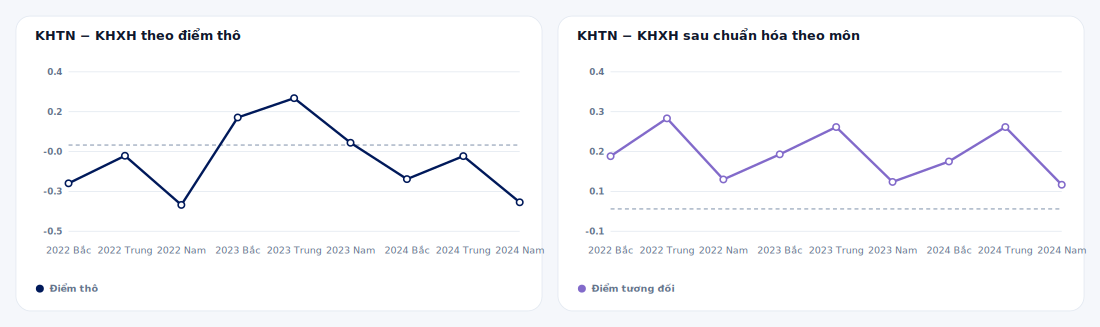

In [9]:
from IPython.display import Markdown, SVG, display
from pathlib import Path

ASSET_DIR = Path('../frontend/public/report')
display(Markdown('Hình minh họa được xuất trực tiếp từ component biểu đồ của ứng dụng dashboard và bao gồm tiêu đề, chú thích cùng toàn bộ vùng biểu đồ.'))
display(SVG(filename=str(ASSET_DIR / 'program.svg')))


## Câu hỏi 2 — Kết quả và diễn giải

### Cách đọc hai biểu đồ

Trục tung biểu diễn chênh lệch KHTN − KHXH. Giá trị dương cho biết KHTN cao hơn KHXH; giá trị âm cho biết KHXH cao hơn. Đường ngang tại mức 0 giúp xác định trực tiếp hướng lợi thế ở từng tổ hợp vùng–năm.

### Kết quả theo điểm gốc

Biểu đồ bên trái cho thấy KHTN có chênh lệch dương trong **3/9 tổ hợp vùng–năm**; ở 6 tổ hợp còn lại, chênh lệch âm, tức KHXH có điểm gốc cao hơn.

### Kết quả sau chuẩn hóa

Biểu đồ bên phải cho thấy cả **9/9 tổ hợp vùng–năm** đều có chênh lệch dương. Sau khi đưa từng môn về mặt bằng so sánh chung, lợi thế quan sát được chuyển nhất quán sang KHTN.

### Trả lời câu hỏi nghiên cứu

**Không có ban nào luôn có kết quả cao hơn theo mọi thước đo. KHXH chiếm ưu thế trong phần lớn tổ hợp khi xét điểm gốc, trong khi KHTN có lợi thế ở toàn bộ 9 tổ hợp khi xét chênh lệch điểm tương đối.** Đây là kết luận được suy ra trực tiếp từ dấu và số lần vượt qua đường 0 trên hai biểu đồ.

Hai kết quả không mâu thuẫn. Điểm gốc trả lời câu hỏi về số điểm thực nhận; điểm tương đối trả lời câu hỏi về vị trí của kết quả trong phân phối điểm của từng môn. Vì vậy, mỗi thước đo tương ứng với một mục tiêu so sánh khác nhau.

### Hàm ý sử dụng kết quả

Trong báo cáo hoặc bảng xếp hạng KHTN–KHXH, nên trình bày đồng thời:

1. điểm gốc, vì đây là điểm thí sinh thực tế nhận được;
2. điểm tương đối theo môn–năm, để giảm ảnh hưởng của khác biệt mặt bằng điểm;
3. tỷ lệ đạt các ngưỡng điểm, vì chỉ số này gần với nhiều mục tiêu xét tuyển hơn.

Không nên suy diễn rằng một ban “dễ hơn” hoặc “tốt hơn” chỉ từ chênh lệch điểm trung bình. Cần đồng thời xem xét cơ cấu môn thi, lựa chọn của thí sinh và đặc điểm phân phối điểm của từng môn.

### Giới hạn

Chuẩn hóa cải thiện tính phù hợp của phép so sánh về mặt thống kê nhưng không loại bỏ hoàn toàn khác biệt về lựa chọn môn, điều kiện học tập hoặc năng lực đầu vào. Kết quả nên được diễn giải là lợi thế theo từng thước đo, không phải bằng chứng về quan hệ nhân quả hay về độ khó tuyệt đối của một ban thi.

## Tổng kết

### Kết luận chính

1. **Chênh lệch vùng miền phụ thuộc vào môn học và nhóm điểm được xét.** Ngoại ngữ có khoảng cách lớn nhất về điểm trung bình, trong khi Ngữ văn có khoảng cách lớn nhất ở nhóm đạt từ 8 điểm trở lên.
2. **Điểm gốc và điểm tương đối trả lời hai câu hỏi khác nhau.** KHXH có lợi thế trong phần lớn so sánh theo điểm gốc, còn KHTN có lợi thế nhất quán khi so sánh vị trí tương đối theo từng môn.

### Khuyến nghị diễn giải

Kết quả phân tích nên được trình bày cùng với định nghĩa chỉ số, phạm vi dữ liệu và giới hạn diễn giải. Việc kết hợp nhiều thước đo giúp hạn chế kết luận đơn giản hóa và hỗ trợ đánh giá kết quả thi một cách minh bạch, có điều kiện và phù hợp với mục tiêu sử dụng dữ liệu.